# Animal Species Classification: Custom CNN vs Fine-Tuned ResNet

**Dataset:** Animals-10 (Kaggle)
**Task:** Multi-class image classification (10 animal species)
**Models compared:**
1. **Custom CNN** — built and trained entirely from scratch (no pretrained weights)
2. **Fine-tuned ResNet18** — pretrained on ImageNet, partially frozen, fine-tuned on Animals-10

This notebook trains both models, evaluates them with the same metrics, and produces side-by-side comparison plots.

> Runtime: Colab GPU recommended. `Runtime > Change runtime type > GPU (T4)`


## 1. Setup & Installs

In [4]:
# Core installs (Colab usually has most of these, this just ensures versions line up)
!pip install -q kaggle torchmetrics


In [5]:
import os, time, json, random, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


## 2. Download Animals-10 Dataset (Kaggle API)

You need a Kaggle API token (`kaggle.json`). Get it from:
**Kaggle → Account Settings → API → Create New Token**

Upload the downloaded `kaggle.json` when prompted below.


In [6]:
from google.colab import files

if not os.path.exists("/root/.kaggle/kaggle.json"):
    print("Upload your kaggle.json file:")
    uploaded = files.upload()  # upload kaggle.json here
    os.makedirs("/root/.kaggle", exist_ok=True)
    for fname in uploaded.keys():
        os.rename(fname, "/root/.kaggle/kaggle.json")
    os.chmod("/root/.kaggle/kaggle.json", 0o600)
    print("kaggle.json installed.")
else:
    print("kaggle.json already present.")


Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
kaggle.json installed.


In [7]:
# Download Animals-10 dataset
# Kaggle dataset ref: alessiocorrado99/animals10
DATA_ROOT = "/content/animals10"
os.makedirs(DATA_ROOT, exist_ok=True)

!kaggle datasets download -d alessiocorrado99/animals10 -p {DATA_ROOT} --unzip

print("\nTop-level contents:")
print(os.listdir(DATA_ROOT))


Dataset URL: https://www.kaggle.com/datasets/alessiocorrado99/animals10
License(s): GPL-2.0
100% 586M/586M [00:04<00:00, 146MB/s]


Top-level contents:
['raw-img', 'translate.py']


In [8]:
# The dataset extracts to: animals10/raw-img/<class_name>/*.jpeg
# Italian folder names map to English class names (translate.py is included in the dataset, but we hardcode the mapping here for clarity)
IT_TO_EN = {
    "cane": "dog", "cavallo": "horse", "elefante": "elephant", "farfalla": "butterfly",
    "gallina": "chicken", "gatto": "cat", "mucca": "cow", "pecora": "sheep",
    "scoiattolo": "squirrel", "ragno": "spider"
}

RAW_IMG_DIR = os.path.join(DATA_ROOT, "raw-img")
print("Classes found:", sorted(os.listdir(RAW_IMG_DIR)))

# Count images per class
class_counts = {}
for cls in sorted(os.listdir(RAW_IMG_DIR)):
    cls_path = os.path.join(RAW_IMG_DIR, cls)
    if os.path.isdir(cls_path):
        n = len([f for f in os.listdir(cls_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
        class_counts[IT_TO_EN.get(cls, cls)] = n

counts_df = pd.DataFrame(list(class_counts.items()), columns=["class", "count"]).sort_values("count", ascending=False)
print(counts_df)
print("\nTotal images:", counts_df["count"].sum())


Classes found: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']
       class  count
0        dog   4863
8     spider   4821
4    chicken   3098
1      horse   2623
3  butterfly   2112
6        cow   1866
9   squirrel   1862
7      sheep   1820
5        cat   1668
2   elephant   1446

Total images: 26179


/tmp/ipykernel_1809/3088180077.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counts_df, x="class", y="count", palette="viridis")


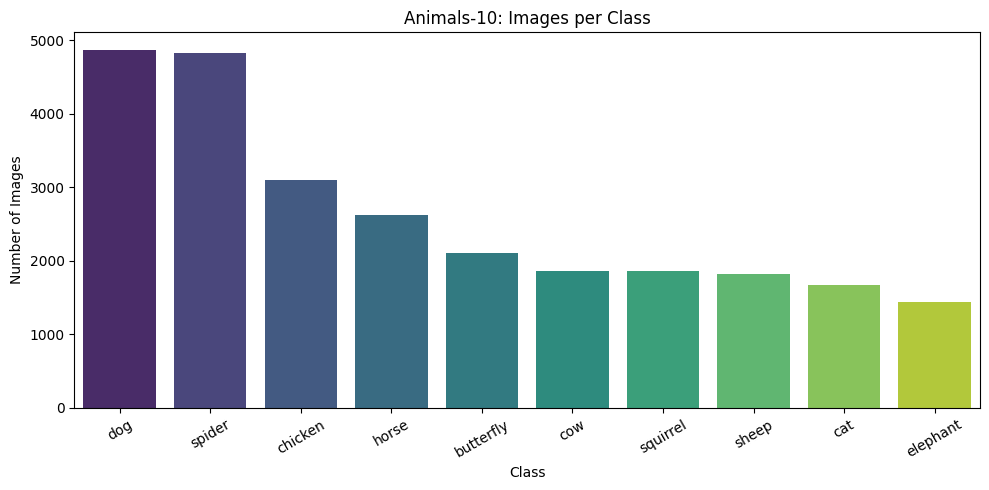

In [9]:
# Visualize class distribution (dataset is naturally imbalanced)
plt.figure(figsize=(10, 5))
sns.barplot(data=counts_df, x="class", y="count", palette="viridis")
plt.title("Animals-10: Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 3. Data Pipeline — Transforms, Splits, DataLoaders

Two separate transform pipelines:
- **CNN (from scratch):** smaller input size (e.g. 96x96) since it has no pretrained prior — keeps training fast and reduces overfitting risk with fewer parameters needed.
- **ResNet:** must use 224x224 + ImageNet normalization stats, since the pretrained weights expect that exact input distribution.


In [10]:
IMG_SIZE_CNN = 96
IMG_SIZE_RESNET = 224

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ---- Transforms for the CUSTOM CNN ----
train_tf_cnn = transforms.Compose([
    transforms.Resize((IMG_SIZE_CNN, IMG_SIZE_CNN)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])
eval_tf_cnn = transforms.Compose([
    transforms.Resize((IMG_SIZE_CNN, IMG_SIZE_CNN)),
    transforms.ToTensor(),
])

# ---- Transforms for RESNET (must match ImageNet preprocessing) ----
train_tf_resnet = transforms.Compose([
    transforms.Resize((IMG_SIZE_RESNET, IMG_SIZE_RESNET)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tf_resnet = transforms.Compose([
    transforms.Resize((IMG_SIZE_RESNET, IMG_SIZE_RESNET)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


In [11]:
# Load full dataset once with ImageFolder (folder names = labels)
# We load it twice with different transforms is wasteful; instead we split indices once
# and wrap with a custom Dataset that applies the right transform per model.

base_dataset = datasets.ImageFolder(RAW_IMG_DIR)  # no transform yet, just for indices/classes
class_names_it = base_dataset.classes
class_names = [IT_TO_EN.get(c, c) for c in class_names_it]
num_classes = len(class_names)
print("Class index mapping:")
for i, c in enumerate(class_names):
    print(f"  {i}: {c}")

n_total = len(base_dataset)
n_train = int(0.7 * n_total)
n_val   = int(0.15 * n_total)
n_test  = n_total - n_train - n_val

train_idx, val_idx, test_idx = random_split(
    range(n_total), [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)
print(f"\nTrain: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")


Class index mapping:
  0: dog
  1: horse
  2: elephant
  3: butterfly
  4: chicken
  5: cat
  6: cow
  7: sheep
  8: spider
  9: squirrel

Train: 18325 | Val: 3926 | Test: 3928


In [14]:
from torch.utils.data import Dataset
from PIL import Image

class TransformSubset(Dataset):
    """Applies a given transform to a subset of an ImageFolder-style dataset."""
    def __init__(self, image_folder, indices, transform):
        self.samples = [image_folder.samples[i] for i in indices]
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        img = self.transform(img)
        return img, label

# Datasets for CNN
train_ds_cnn = TransformSubset(base_dataset, train_idx, train_tf_cnn)
val_ds_cnn   = TransformSubset(base_dataset, val_idx, eval_tf_cnn)
test_ds_cnn  = TransformSubset(base_dataset, test_idx, eval_tf_cnn)

# Datasets for ResNet
train_ds_resnet = TransformSubset(base_dataset, train_idx, train_tf_resnet)
val_ds_resnet   = TransformSubset(base_dataset, val_idx, eval_tf_resnet)
test_ds_resnet  = TransformSubset(base_dataset, test_idx, eval_tf_resnet)

BATCH_SIZE = 32
NUM_WORKERS = 2

def make_loaders(train_ds, val_ds, test_ds):
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=NUM_WORKERS, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=True)
    test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=True)
    return train_loader, val_loader, test_loader

train_loader_cnn, val_loader_cnn, test_loader_cnn = make_loaders(train_ds_cnn, val_ds_cnn, test_ds_cnn)
train_loader_resnet, val_loader_resnet, test_loader_resnet = make_loaders(train_ds_resnet, val_ds_resnet, test_ds_resnet)

print("DataLoaders ready.")


DataLoaders ready.


Sample batch (CNN pipeline, no normalization):


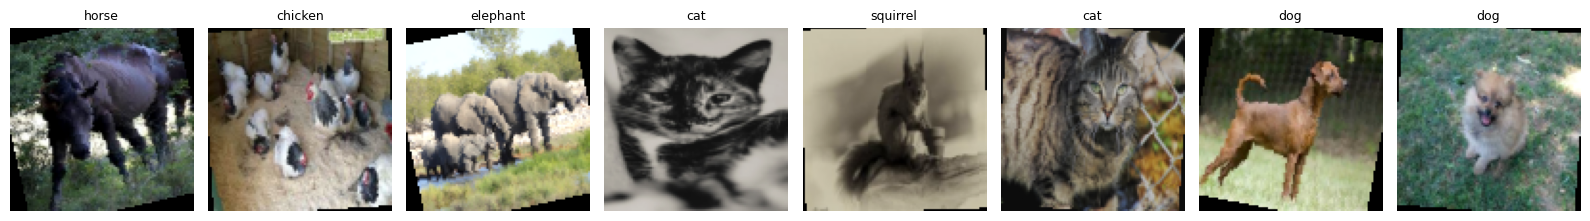

In [15]:
# Sanity check: show a few sample images with labels
def show_batch(loader, class_names, mean=None, std=None, n=8):
    imgs, labels = next(iter(loader))
    imgs = imgs[:n]
    labels = labels[:n]
    fig, axes = plt.subplots(1, n, figsize=(2*n, 2.5))
    for i in range(n):
        img = imgs[i].permute(1, 2, 0).numpy()
        if mean is not None:
            img = img * np.array(std) + np.array(mean)
        img = np.clip(img, 0, 1)
        axes[i].imshow(img)
        axes[i].set_title(class_names[labels[i]], fontsize=9)
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

print("Sample batch (CNN pipeline, no normalization):")
show_batch(train_loader_cnn, class_names)


## 4. Model A — Custom CNN (Trained From Scratch)

This is a CNN designed and trained entirely from scratch — **no pretrained weights anywhere**.
Architecture: 4 conv blocks (Conv → BatchNorm → ReLU → MaxPool) followed by a classifier head.


In [16]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=10, img_size=96):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # /2

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # /4

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # /8

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # /16
        )
        self.gap = nn.AdaptiveAvgPool2d(1)  # global average pool -> works for any input size
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

cnn_model = CustomCNN(num_classes=num_classes, img_size=IMG_SIZE_CNN).to(device)

total_params = sum(p.numel() for p in cnn_model.parameters())
trainable_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"Custom CNN — Total params: {total_params:,} | Trainable params: {trainable_params:,}")
print("(100% trainable — entire model trained from scratch, 0 frozen layers)")


Custom CNN — Total params: 423,562 | Trainable params: 423,562
(100% trainable — entire model trained from scratch, 0 frozen layers)


## 5. Model B — Fine-Tuned ResNet18 (Transfer Learning)

We load ResNet18 pretrained on ImageNet, then **freeze most of the network** and only
fine-tune the later layers + classifier head. This is the standard transfer-learning
approach when your target domain (real animal photos) is similar to ImageNet's domain.

**Freeze configuration is a single variable below (`FREEZE_UPTO`)** — change it to experiment
with shallower or deeper fine-tuning.

ResNet18 layer groups, in order: `conv1, bn1, layer1, layer2, layer3, layer4, fc`


In [17]:
# ---- CONFIG: change this single value to control how much of ResNet is frozen ----
# Options: "conv1", "layer1", "layer2", "layer3", "layer4", "none"
# Everything UP TO AND INCLUDING this group is frozen; everything after it is trainable.
FREEZE_UPTO = "layer3"   # default: freeze conv1,bn1,layer1,layer2,layer3 -> train layer4 + fc

resnet_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Replace the final classifier head for our 10 classes
in_features = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(in_features, num_classes)

# Define the layer groups in architectural order
layer_groups = ["conv1", "bn1", "layer1", "layer2", "layer3", "layer4", "fc"]
freeze_order = ["conv1", "layer1", "layer2", "layer3", "layer4"]  # bn1 freezes with conv1

if FREEZE_UPTO == "none":
    freeze_cutoff_idx = -1
else:
    freeze_cutoff_idx = freeze_order.index(FREEZE_UPTO)

frozen_groups = []
trainable_groups = []

for name, module in resnet_model.named_children():
    group_key = name if name != "bn1" else "conv1"  # bn1 tied to conv1's freeze decision
    if group_key in freeze_order and freeze_order.index(group_key) <= freeze_cutoff_idx:
        for p in module.parameters():
            p.requires_grad = False
        frozen_groups.append(name)
    else:
        for p in module.parameters():
            p.requires_grad = True
        trainable_groups.append(name)

resnet_model = resnet_model.to(device)

total_params = sum(p.numel() for p in resnet_model.parameters())
trainable_params = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"Freeze config: freeze up to and including '{FREEZE_UPTO}'\n")
print(f"Frozen layer groups   : {frozen_groups}")
print(f"Trainable layer groups: {trainable_groups}\n")
print(f"Total params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,}  ({100*trainable_params/total_params:.1f}%)")
print(f"Frozen params    : {frozen_params:,}  ({100*frozen_params/total_params:.1f}%)")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 125MB/s]


Freeze config: freeze up to and including 'layer3'

Frozen layer groups   : ['conv1', 'bn1', 'layer1', 'layer2', 'layer3']
Trainable layer groups: ['relu', 'maxpool', 'layer4', 'avgpool', 'fc']

Total params     : 11,181,642
Trainable params : 8,398,858  (75.1%)
Frozen params    : 2,782,784  (24.9%)


In [18]:
# Detailed per-layer freeze report (useful to paste into your report)
print(f"{'Layer name':30s} {'Trainable':>10s} {'#Params':>12s}")
print("-" * 56)
for name, module in resnet_model.named_children():
    n_params = sum(p.numel() for p in module.parameters())
    is_trainable = any(p.requires_grad for p in module.parameters())
    print(f"{name:30s} {str(is_trainable):>10s} {n_params:>12,}")


Layer name                      Trainable      #Params
--------------------------------------------------------
conv1                               False        9,408
bn1                                 False          128
relu                                False            0
maxpool                             False            0
layer1                              False      147,968
layer2                              False      525,568
layer3                              False    2,099,712
layer4                               True    8,393,728
avgpool                             False            0
fc                                   True        5,130


## 6. Shared Training Loop

Same training function used for both models so the comparison is fair (same optimizer style,
same epoch logic, same metric tracking).


In [19]:
def train_model(model, train_loader, val_loader, num_epochs=10, lr=1e-3, model_name="model"):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    # Only optimize parameters that require grad (matters for frozen ResNet layers)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = 0.0
    best_state = None
    start_time = time.time()

    for epoch in range(num_epochs):
        # ---- Train ----
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # ---- Validate ----
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * imgs.size(0)
                preds = outputs.argmax(1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        print(f"[{model_name}] Epoch {epoch+1}/{num_epochs} | "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    total_time = time.time() - start_time
    print(f"\n[{model_name}] Training complete in {total_time/60:.1f} min. Best val_acc: {best_val_acc:.4f}")

    model.load_state_dict(best_state)
    return model, history, total_time


## 7. Train Both Models

In [20]:
NUM_EPOCHS_CNN = 15

cnn_model, cnn_history, cnn_train_time = train_model(
    cnn_model, train_loader_cnn, val_loader_cnn,
    num_epochs=NUM_EPOCHS_CNN, lr=1e-3, model_name="CustomCNN"
)


[CustomCNN] Epoch 1/15 | train_loss=1.8815 train_acc=0.3379 | val_loss=1.7482 val_acc=0.3963
[CustomCNN] Epoch 2/15 | train_loss=1.5512 train_acc=0.4526 | val_loss=1.3595 val_acc=0.5278
[CustomCNN] Epoch 3/15 | train_loss=1.3893 train_acc=0.5163 | val_loss=1.2949 val_acc=0.5415
[CustomCNN] Epoch 4/15 | train_loss=1.2856 train_acc=0.5509 | val_loss=1.1826 val_acc=0.5820
[CustomCNN] Epoch 5/15 | train_loss=1.2198 train_acc=0.5824 | val_loss=1.2292 val_acc=0.5678
[CustomCNN] Epoch 6/15 | train_loss=1.1510 train_acc=0.6065 | val_loss=1.2110 val_acc=0.5759
[CustomCNN] Epoch 7/15 | train_loss=1.1071 train_acc=0.6207 | val_loss=1.2044 val_acc=0.5965
[CustomCNN] Epoch 8/15 | train_loss=0.9901 train_acc=0.6637 | val_loss=0.9310 val_acc=0.6867
[CustomCNN] Epoch 9/15 | train_loss=0.9471 train_acc=0.6787 | val_loss=0.8763 val_acc=0.7012
[CustomCNN] Epoch 10/15 | train_loss=0.9159 train_acc=0.6847 | val_loss=1.0870 val_acc=0.6363
[CustomCNN] Epoch 11/15 | train_loss=0.9065 train_acc=0.6931 | val_lo

In [21]:
NUM_EPOCHS_RESNET = 10  # ResNet usually needs fewer epochs since it starts pretrained

resnet_model, resnet_history, resnet_train_time = train_model(
    resnet_model, train_loader_resnet, val_loader_resnet,
    num_epochs=NUM_EPOCHS_RESNET, lr=1e-4, model_name="ResNet18-FineTuned"
)


[ResNet18-FineTuned] Epoch 1/10 | train_loss=0.3024 train_acc=0.9099 | val_loss=0.1639 val_acc=0.9493
[ResNet18-FineTuned] Epoch 2/10 | train_loss=0.1380 train_acc=0.9563 | val_loss=0.1472 val_acc=0.9564
[ResNet18-FineTuned] Epoch 3/10 | train_loss=0.0911 train_acc=0.9722 | val_loss=0.1417 val_acc=0.9552
[ResNet18-FineTuned] Epoch 4/10 | train_loss=0.0757 train_acc=0.9759 | val_loss=0.1330 val_acc=0.9598
[ResNet18-FineTuned] Epoch 5/10 | train_loss=0.0578 train_acc=0.9825 | val_loss=0.1237 val_acc=0.9615
[ResNet18-FineTuned] Epoch 6/10 | train_loss=0.0458 train_acc=0.9852 | val_loss=0.1422 val_acc=0.9587
[ResNet18-FineTuned] Epoch 7/10 | train_loss=0.0390 train_acc=0.9873 | val_loss=0.1623 val_acc=0.9531
[ResNet18-FineTuned] Epoch 8/10 | train_loss=0.0329 train_acc=0.9901 | val_loss=0.1777 val_acc=0.9552
[ResNet18-FineTuned] Epoch 9/10 | train_loss=0.0188 train_acc=0.9951 | val_loss=0.1400 val_acc=0.9633
[ResNet18-FineTuned] Epoch 10/10 | train_loss=0.0145 train_acc=0.9962 | val_loss=0

## 8. Evaluation on Held-Out Test Set

Same evaluation function applied to both models: accuracy, precision, recall, F1, confusion matrix.


In [22]:
def evaluate_model(model, test_loader, class_names, model_name="model"):
    model.eval()
    all_preds, all_labels = [], []
    inference_start = time.time()
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    inference_time = time.time() - inference_start

    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="weighted", zero_division=0
    )
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=class_names, zero_division=0)

    print(f"=== {model_name} — Test Set Results ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"Inference time (full test set): {inference_time:.2f}s\n")
    print(report)

    return {
        "model_name": model_name,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm,
        "inference_time": inference_time,
        "y_true": all_labels,
        "y_pred": all_preds,
    }

cnn_results = evaluate_model(cnn_model, test_loader_cnn, class_names, "Custom CNN")


=== Custom CNN — Test Set Results ===
Accuracy : 0.7235
Precision: 0.7431
Recall   : 0.7235
F1-score : 0.7158
Inference time (full test set): 7.48s

              precision    recall  f1-score   support

         dog       0.62      0.85      0.72       736
       horse       0.67      0.76      0.71       409
    elephant       0.98      0.37      0.54       218
   butterfly       0.85      0.72      0.78       332
     chicken       0.82      0.87      0.84       451
         cat       0.68      0.33      0.45       250
         cow       0.55      0.70      0.61       277
       sheep       0.72      0.49      0.59       269
      spider       0.87      0.85      0.86       707
    squirrel       0.68      0.67      0.67       279

    accuracy                           0.72      3928
   macro avg       0.74      0.66      0.68      3928
weighted avg       0.74      0.72      0.72      3928



In [23]:
resnet_results = evaluate_model(resnet_model, test_loader_resnet, class_names, "ResNet18 (Fine-Tuned)")


=== ResNet18 (Fine-Tuned) — Test Set Results ===
Accuracy : 0.9674
Precision: 0.9675
Recall   : 0.9674
F1-score : 0.9674
Inference time (full test set): 13.10s

              precision    recall  f1-score   support

         dog       0.97      0.96      0.97       736
       horse       0.96      0.96      0.96       409
    elephant       0.98      1.00      0.99       218
   butterfly       0.96      0.98      0.97       332
     chicken       0.97      0.97      0.97       451
         cat       0.95      0.97      0.96       250
         cow       0.93      0.94      0.93       277
       sheep       0.94      0.96      0.95       269
      spider       0.99      0.98      0.99       707
    squirrel       0.99      0.96      0.97       279

    accuracy                           0.97      3928
   macro avg       0.96      0.97      0.97      3928
weighted avg       0.97      0.97      0.97      3928



## 9. Side-by-Side Comparison

In [24]:
comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score",
               "Total Params", "Trainable Params", "Frozen Params (%)",
               "Training Time (min)", "Inference Time (s, full test set)"],
    "Custom CNN": [
        f"{cnn_results['accuracy']:.4f}",
        f"{cnn_results['precision']:.4f}",
        f"{cnn_results['recall']:.4f}",
        f"{cnn_results['f1']:.4f}",
        f"{sum(p.numel() for p in cnn_model.parameters()):,}",
        f"{sum(p.numel() for p in cnn_model.parameters() if p.requires_grad):,}",
        "0% (trained fully from scratch)",
        f"{cnn_train_time/60:.1f}",
        f"{cnn_results['inference_time']:.2f}",
    ],
    "ResNet18 (Fine-Tuned)": [
        f"{resnet_results['accuracy']:.4f}",
        f"{resnet_results['precision']:.4f}",
        f"{resnet_results['recall']:.4f}",
        f"{resnet_results['f1']:.4f}",
        f"{sum(p.numel() for p in resnet_model.parameters()):,}",
        f"{sum(p.numel() for p in resnet_model.parameters() if p.requires_grad):,}",
        f"{100*(1 - sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)/sum(p.numel() for p in resnet_model.parameters())):.1f}% "
        f"(frozen: {frozen_groups})",
        f"{resnet_train_time/60:.1f}",
        f"{resnet_results['inference_time']:.2f}",
    ],
})

comparison_df


,Metric,Custom CNN,ResNet18 (Fine-Tuned)
0,Accuracy,0.7235,0.9674
1,Precision,0.7431,0.9675
2,Recall,0.7235,0.9674
3,F1-score,0.7158,0.9674
4,Total Params,"423,562","11,181,642"
5,Trainable Params,"423,562","8,398,858"
6,Frozen Params (%),0% (trained fully from scratch),"24.9% (frozen: ['conv1', 'bn1', 'layer1', 'lay..."
7,Training Time (min),12.0,16.0
8,"Inference Time (s, full test set)",7.48,13.10


## 10. Graph-Wise Comparison

### 10.1 Training & Validation Curves (per model)

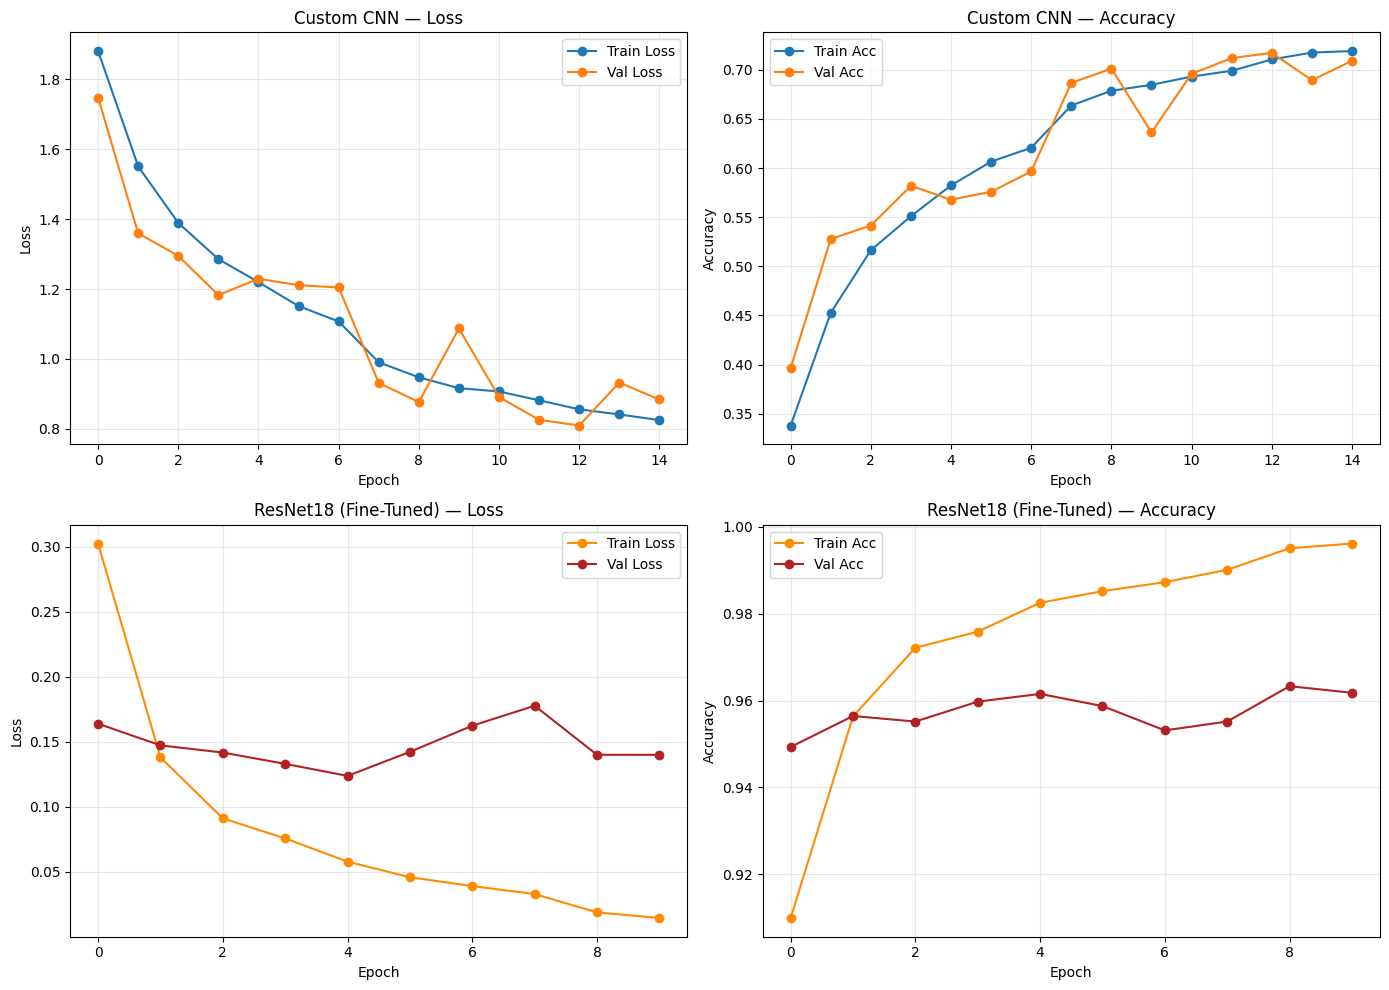

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# CNN curves
axes[0, 0].plot(cnn_history["train_loss"], label="Train Loss", marker="o")
axes[0, 0].plot(cnn_history["val_loss"], label="Val Loss", marker="o")
axes[0, 0].set_title("Custom CNN — Loss")
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss"); axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(cnn_history["train_acc"], label="Train Acc", marker="o")
axes[0, 1].plot(cnn_history["val_acc"], label="Val Acc", marker="o")
axes[0, 1].set_title("Custom CNN — Accuracy")
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Accuracy"); axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

# ResNet curves
axes[1, 0].plot(resnet_history["train_loss"], label="Train Loss", marker="o", color="darkorange")
axes[1, 0].plot(resnet_history["val_loss"], label="Val Loss", marker="o", color="firebrick")
axes[1, 0].set_title("ResNet18 (Fine-Tuned) — Loss")
axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("Loss"); axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(resnet_history["train_acc"], label="Train Acc", marker="o", color="darkorange")
axes[1, 1].plot(resnet_history["val_acc"], label="Val Acc", marker="o", color="firebrick")
axes[1, 1].set_title("ResNet18 (Fine-Tuned) — Accuracy")
axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("Accuracy"); axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 10.2 Validation Accuracy: CNN vs ResNet (overlaid)

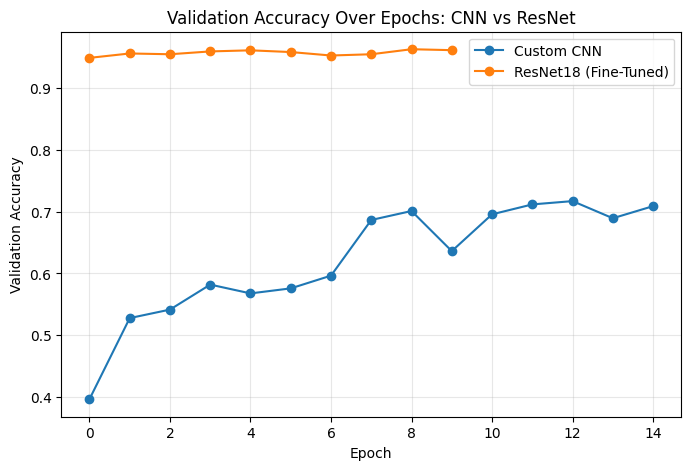

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(cnn_history["val_acc"], label="Custom CNN", marker="o")
plt.plot(resnet_history["val_acc"], label="ResNet18 (Fine-Tuned)", marker="o")
plt.title("Validation Accuracy Over Epochs: CNN vs ResNet")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### 10.3 Final Test Metrics — Bar Chart Comparison

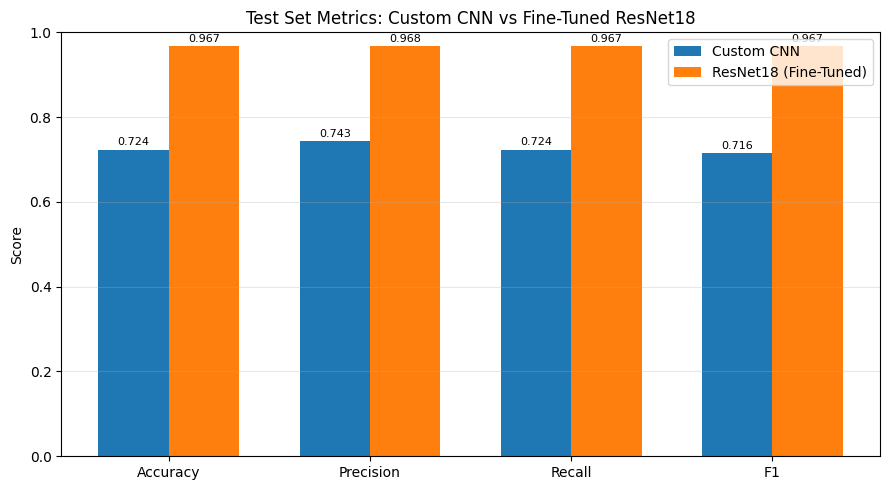

In [27]:
metrics = ["accuracy", "precision", "recall", "f1"]
cnn_vals = [cnn_results[m] for m in metrics]
resnet_vals = [resnet_results[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, cnn_vals, width, label="Custom CNN")
ax.bar(x + width/2, resnet_vals, width, label="ResNet18 (Fine-Tuned)")
ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in metrics])
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("Test Set Metrics: Custom CNN vs Fine-Tuned ResNet18")
ax.legend()
ax.grid(alpha=0.3, axis="y")

for i, v in enumerate(cnn_vals):
    ax.text(i - width/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=8)
for i, v in enumerate(resnet_vals):
    ax.text(i + width/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()


### 10.4 Confusion Matrices (side by side)

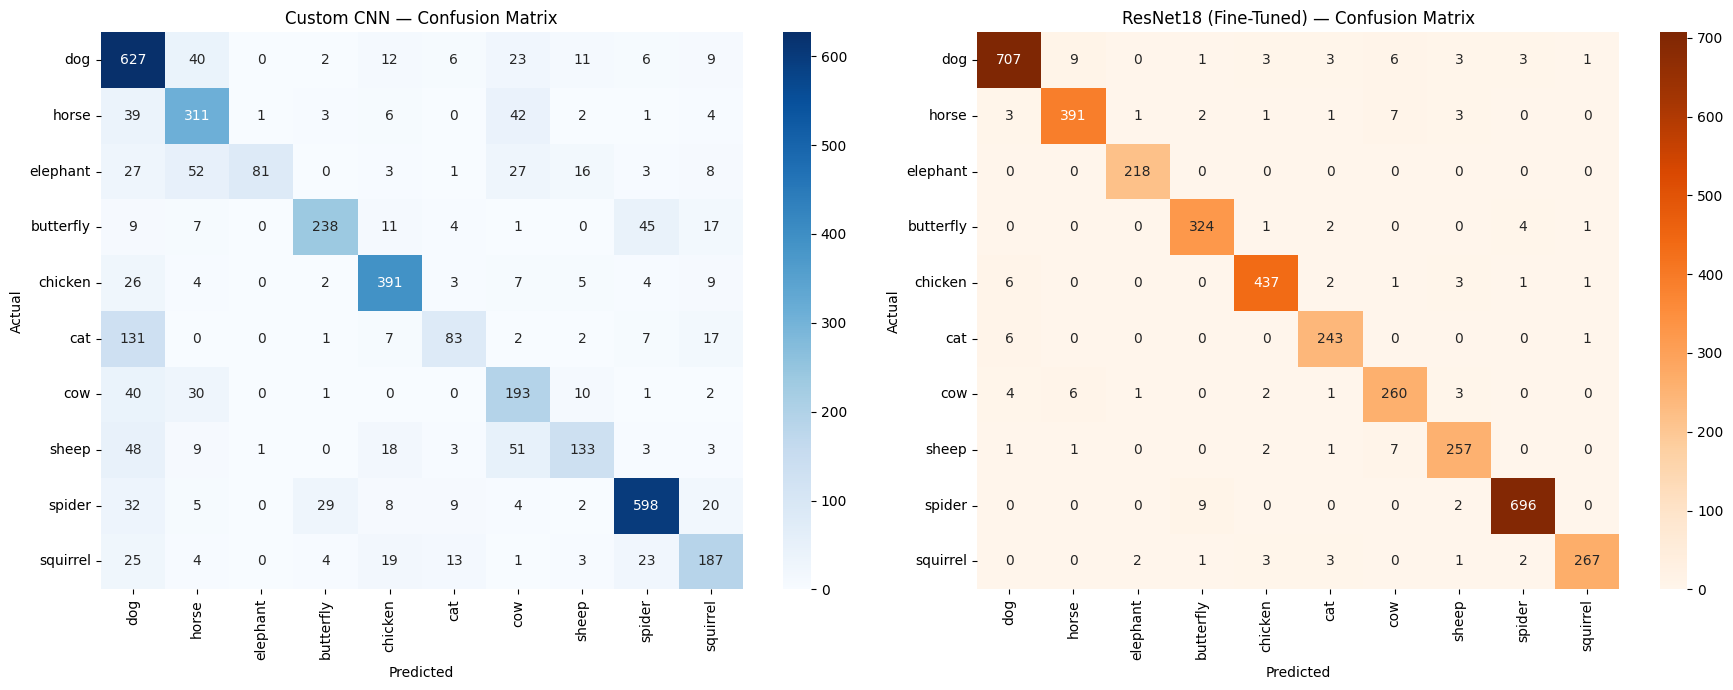

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cnn_results["confusion_matrix"], annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title("Custom CNN — Confusion Matrix")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

sns.heatmap(resnet_results["confusion_matrix"], annot=True, fmt="d", cmap="Oranges",
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title("ResNet18 (Fine-Tuned) — Confusion Matrix")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


### 10.5 Model Efficiency: Params & Training Time

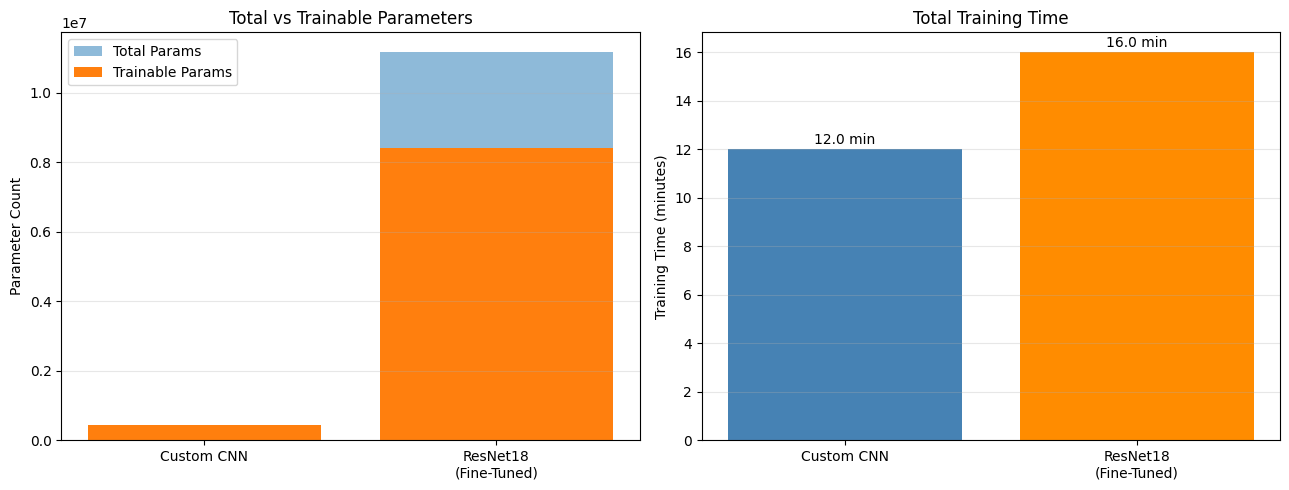

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

model_labels = ["Custom CNN", "ResNet18\n(Fine-Tuned)"]

# Trainable params comparison
trainable_counts = [
    sum(p.numel() for p in cnn_model.parameters() if p.requires_grad),
    sum(p.numel() for p in resnet_model.parameters() if p.requires_grad),
]
total_counts = [
    sum(p.numel() for p in cnn_model.parameters()),
    sum(p.numel() for p in resnet_model.parameters()),
]

x = np.arange(len(model_labels))
axes[0].bar(x, total_counts, label="Total Params", alpha=0.5)
axes[0].bar(x, trainable_counts, label="Trainable Params")
axes[0].set_xticks(x); axes[0].set_xticklabels(model_labels)
axes[0].set_ylabel("Parameter Count")
axes[0].set_title("Total vs Trainable Parameters")
axes[0].legend()
axes[0].grid(alpha=0.3, axis="y")

# Training time comparison
train_times = [cnn_train_time/60, resnet_train_time/60]
axes[1].bar(model_labels, train_times, color=["steelblue", "darkorange"])
axes[1].set_ylabel("Training Time (minutes)")
axes[1].set_title("Total Training Time")
axes[1].grid(alpha=0.3, axis="y")
for i, v in enumerate(train_times):
    axes[1].text(i, v + 0.2, f"{v:.1f} min", ha="center")

plt.tight_layout()
plt.show()


In [30]:
from google.colab import files
from PIL import Image
import io

def predict_single(model, model_name, input_tensor, class_names):
    model.eval()
    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)[0]
    pred_idx = probs.argmax().item()
    return class_names[pred_idx], probs[pred_idx].item()

Saving a.jpg to a (1).jpg


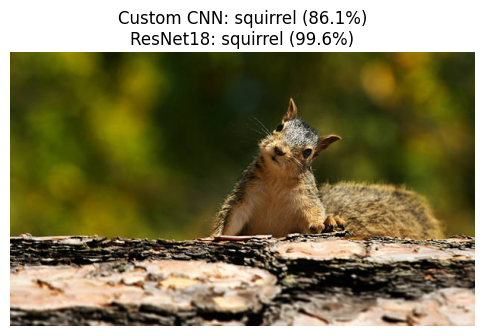

In [31]:
# Upload an image for prediction
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

img = Image.open(img_path).convert('RGB')

# --- Custom CNN Prediction ---
cnn_input_tensor = eval_tf_cnn(img).unsqueeze(0).to(device)
cnn_label, cnn_conf = predict_single(cnn_model, "CustomCNN", cnn_input_tensor, class_names)

# --- ResNet18 Prediction ---
resnet_input_tensor = eval_tf_resnet(img).unsqueeze(0).to(device)
resnet_label, resnet_conf = predict_single(resnet_model, "ResNet18", resnet_input_tensor, class_names)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
plt.title(
    f"Custom CNN: {cnn_label} ({cnn_conf*100:.1f}%)\n"
    f"ResNet18: {resnet_label} ({resnet_conf*100:.1f}%)"
)
plt.show()